Проверка моделей с промежуточными значениями

# Загрузка библиотек

In [13]:
import pandas as pd
import numpy as np
import sys
import random
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC

In [2]:
sys.path.append('../utils_functionality/')
from data_analysis.split_analisys import *
from data_analysis.reports import *
from models.class_models import *
from models.class_models import *
from models.hyperparams_tuning import *
from models.blending import *

Imported 0.2.6 version. Select nrows to a small number when running on huge datasets.
output = featurewiz(dataname, target, corr_limit=0.90, verbose=2, sep=',', 
		header=0, test_data='',feature_engg='', category_encoders='',
		dask_xgboost_flag=False, nrows=None, skip_sulov=False)
Create new features via 'feature_engg' flag : ['interactions','groupby','target']



In [3]:
import wandb
wandb.login(key='8b1f2ae49570ea59dc8612ff434ca497d463d221')

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: dimazharikov10 (dstech). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\dimaz/.netrc


True

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
RANDOM_STATE = 42

# Загрузка данных и разделение на train, test

In [6]:
df = pd.read_excel('../data/df_merged_edited.xlsx', index_col=[0])
stranger_things = ['voltage', 'long_impulse_duration', 'long_impulse_dur_binary']
train, test = train_test_split(df, test_size=0.33, random_state=RANDOM_STATE)

# Добавляем промежуточные значения Re

# splashing

## featurewiz + CatBoost + SMOTENC + optuna, no strange columns

In [7]:
cs = CreateSamples(df, train, test, target='splashing', use_featurewiz=True, drop_duplicates=True, strange_columns=stranger_things)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [8]:
df.shape, X_train.shape[0] + X_test.shape[0]

((372, 28), 349)

In [21]:
n = 20
random_ind = random.choices(X_test['Re'].index, k=n)
random_vals = np.random.uniform(X_test['Re'].min(), X_test['Re'].max(), size=n)
X_test.loc[random_ind, 'Re'] = random_vals

In [22]:
smote_nc = SMOTENC(categorical_features=[6], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [23]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC + optuna, splashing, no strange columns, no duplicates, adjacent values'
)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, n_trials=70, timeout=None)

In [26]:
model = CatBoostClassifier(**best_trial_cb.params, verbose=False)
model.fit(X_train, y_train)
model.save_model('../utils_functionality/models/models_pickles/splashing')
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.859375,0.859375,0.859375,64.00
1,0.839286,0.839286,0.839286,56.00
accuracy,0.850000,0.850000,0.850000,0.85
macro avg,0.849330,0.849330,0.849330,120.00
weighted avg,0.850000,0.850000,0.850000,120.00


# net_impact

## featurewiz + CatBoost + SMOTENC + optuna, net_impact, no strange columns

In [27]:
cs = CreateSamples(df, train, test, target='net_impact', use_featurewiz=True, drop_duplicates=True, strange_columns=stranger_things)
X_train, X_test, y_train, y_test = cs.get_samples()

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
#### Single_Label Binary_Classification problem ####
    Loaded train data. Shape = (372, 20)
#### Single_Label Binary_Classification problem ####
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#############################################

In [28]:
df.shape, X_train.shape[0] + X_test.shape[0]

((372, 28), 99)

In [32]:
X_train.head()

,surface_tension,roughness,particle_mean_diameter,inclination,viscosity,wettability
0,0.0691,0.04,0.000041,0,0.00689,2
1,0.0691,10.89,0.000041,0,0.00689,0
2,0.0679,2.49,0.000041,0,0.02310,1
3,0.0679,0.10,0.000041,0,0.02310,0
4,0.0269,0.04,0.000041,0,0.00679,2


In [29]:
smote_nc = SMOTENC(categorical_features=[5], random_state=RANDOM_STATE)
X_train, y_train = smote_nc.fit_resample(X_train, y_train)

In [33]:
n = 20
random_ind = random.choices(X_test['roughness'].index, k=n)
random_vals = np.random.uniform(X_test['roughness'].min(), X_test['roughness'].max(), size=n)
X_test.loc[random_ind, 'roughness'] = random_vals

In [ ]:
wandb.init(
    project='drop-wall-impact-clfr', 
    name='featurewiz + CatBoost + SMOTENC + optuna, net_impact, no strange columns, no duplicates, adjacent values'
)

In [ ]:
best_trial_cb = get_best_trial(X_train, X_test, y_train, y_test, n_trials=70, timeout=None)

In [36]:
model = CatBoostClassifier(**best_trial_cb.params, verbose=False)
model.fit(X_train, y_train)
y_preds = model.predict(X_test)
y_preds_proba = model.predict_proba(X_test)[:, 1]
roc, acc, f1 = get_classification_report(y_train, y_test, y_preds, y_preds_proba, return_metrics=True)
wandb.log({
    'accuracy': acc,
    'ROC-AUC': roc,
    'F1-score': f1
    })

,precision,recall,f1-score,support
0,0.909091,0.857143,0.882353,35.000000
1,0.642857,0.750000,0.692308,12.000000
accuracy,0.829787,0.829787,0.829787,0.829787
macro avg,0.775974,0.803571,0.787330,47.000000
weighted avg,0.841116,0.829787,0.833831,47.000000


#### Cross-Validation

In [39]:
get_cv_results(model, X_train, y_train, X_test, y_test)

F1 Train:	71.72% (std: 9.52%)
F1 Test:	0.00% (std: 0.00%)


#### SHAP interpretation

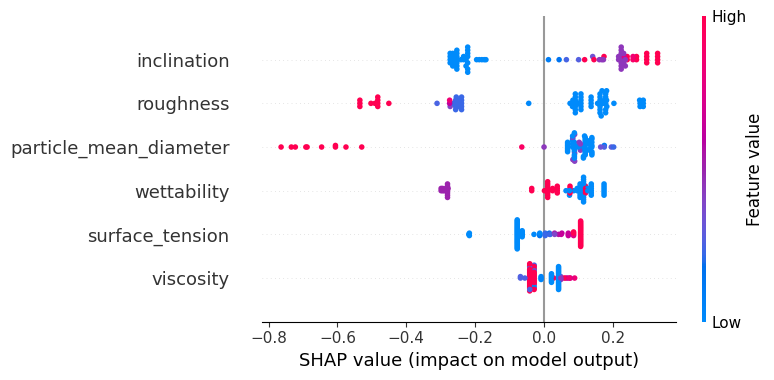

In [38]:
get_shap_interpretation(model, X_train)